# Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import f1_score, classification_report

# Загрузка и очистка данных

In [2]:
# Загрузка данных
df = pd.read_csv('agriculture.csv', sep=';', encoding='cp1251')

# Очистка названий столбцов
df.columns = df.columns.str.strip()

# Приведение строковых значений к единому виду
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

# Удаление лишнего суффикса
df['Наименование вида сельхоз. продукции'] = (
    df['Наименование вида сельхоз. продукции']
    .str.replace(', тыс. штук', '', regex=False)
)

# Функция преобразования в числа
def convert_to_float(series):
    series = series.astype(str).str.replace(',', '.', regex=False).str.strip()
    return pd.to_numeric(series, errors='coerce')

# Преобразование числовых столбцов
df['Показатель, тыс. ед.'] = convert_to_float(df['Показатель, тыс. ед.'])
df['Доля'] = convert_to_float(df['Доля'])
df['Темп роста, %'] = convert_to_float(df['Темп роста, %'])
df['Год'] = pd.to_numeric(df['Год'], errors='coerce')

print(df.head())
print(df.isna().sum())

            Сектор Наименование вида сельхоз. продукции   Год  \
0  растениеводство                   капуста всех видов  1999   
1  растениеводство                   капуста всех видов  2000   
2  растениеводство                   капуста всех видов  2001   
3  растениеводство                   капуста всех видов  2002   
4  растениеводство                   капуста всех видов  2003   

   Показатель, тыс. ед.      Доля  Темп роста, % Категория  
0                166.18  0.002884            NaN   высокий  
1                156.63  0.002820      -5.746781   высокий  
2                146.04  0.002609      -6.761157   высокий  
3                140.55  0.002487      -3.759244   высокий  
4                137.69  0.002613      -2.034863   высокий  
Сектор                                   0
Наименование вида сельхоз. продукции     0
Год                                      0
Показатель, тыс. ед.                     0
Доля                                     0
Темп роста, %               

# Формирование целевой переменной

In [3]:
target_map = {'низкий': 0, 'средний': 1, 'высокий': 2}
df['Категория_ord'] = df['Категория'].map(target_map)

X = df.drop(columns=['Категория', 'Категория_ord'])
y = df['Категория_ord']

print(X.shape)
print(y.value_counts())

(1118, 6)
Категория_ord
2    387
0    387
1    344
Name: count, dtype: int64


# Разделение на обучающую и тестовую выборки

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (894, 6)
Тестовая выборка: (224, 6)


# Подготовка признаков

In [5]:
numeric_features = ['Год', 'Показатель, тыс. ед.', 'Доля', 'Темп роста, %']
categorical_features = ['Сектор', 'Наименование вида сельхоз. продукции']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Создание ансамблевых моделей

In [6]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

et_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ExtraTreesClassifier(
        n_estimators=200,
        random_state=42
    ))
])

ada_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    ))
])

gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ))
])

# Обучение моделей

In [7]:
rf_model.fit(X_train, y_train)
et_model.fit(X_train, y_train)
ada_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['Год',
                                                   'Показатель, тыс. ед.',
                                                   'Доля', 'Темп роста, %']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Сектор',
                                                   'Наименование вида сельхоз. '
                                                   'продукции'])])),
                ('model', GradientBoostingClassifier(random_state=42))])

# Предсказания и оценка качества

In [8]:
y_pred_rf = rf_model.predict(X_test)
y_pred_et = et_model.predict(X_test)
y_pred_ada = ada_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)

results = pd.DataFrame({
    'Модель': [
        'Random Forest',
        'Extra Trees',
        'AdaBoost',
        'Gradient Boosting'
    ],
    'F1-macro': [
        f1_score(y_test, y_pred_rf, average='macro'),
        f1_score(y_test, y_pred_et, average='macro'),
        f1_score(y_test, y_pred_ada, average='macro'),
        f1_score(y_test, y_pred_gb, average='macro')
    ]
})

results = results.sort_values(by='F1-macro', ascending=False).reset_index(drop=True)
print(results)

              Модель  F1-macro
0        Extra Trees  0.796520
1      Random Forest  0.792982
2  Gradient Boosting  0.749919
3           AdaBoost  0.531423


# Подробные результаты по моделям

In [9]:
print("Random Forest")
print(classification_report(y_test, y_pred_rf))

print("Extra Trees")
print(classification_report(y_test, y_pred_et))

print("AdaBoost")
print(classification_report(y_test, y_pred_ada))

print("Gradient Boosting")
print(classification_report(y_test, y_pred_gb))

Random Forest
              precision    recall  f1-score   support

           0       0.84      0.82      0.83        78
           1       0.67      0.72      0.69        69
           2       0.88      0.83      0.85        77

    accuracy                           0.79       224
   macro avg       0.80      0.79      0.79       224
weighted avg       0.80      0.79      0.80       224

Extra Trees
              precision    recall  f1-score   support

           0       0.86      0.83      0.84        78
           1       0.67      0.71      0.69        69
           2       0.87      0.84      0.86        77

    accuracy                           0.80       224
   macro avg       0.80      0.80      0.80       224
weighted avg       0.80      0.80      0.80       224

AdaBoost
              precision    recall  f1-score   support

           0       0.54      0.49      0.51        78
           1       0.53      0.58      0.55        69
           2       0.53      0.53      0

# График сравнения моделей

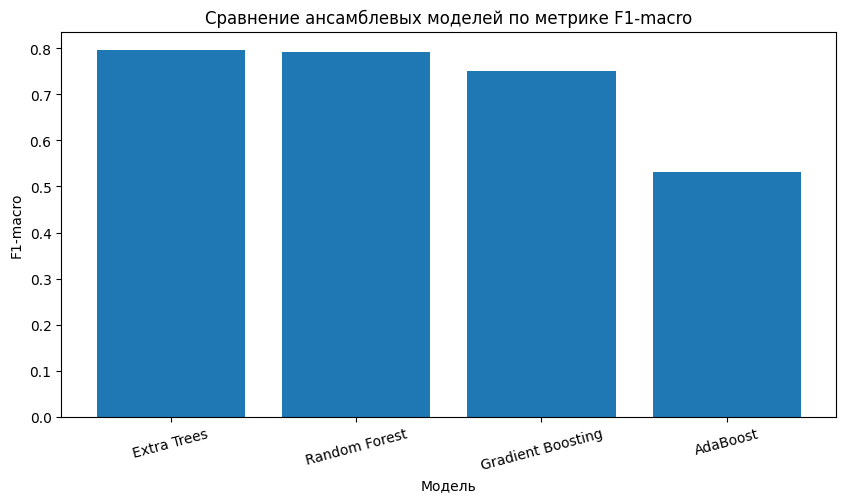

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(results['Модель'], results['F1-macro'])
plt.title('Сравнение ансамблевых моделей по метрике F1-macro')
plt.xlabel('Модель')
plt.ylabel('F1-macro')
plt.xticks(rotation=15)
plt.show()

# Выводы
В лабораторной работе были обучены и сравнены четыре ансамблевые модели: Random Forest, Extra Trees, AdaBoost и Gradient Boosting. Перед обучением выполнена предварительная обработка данных: заполнение пропусков и кодирование категориальных признаков. Качество моделей оценивалось по метрике F1-macro. По результатам сравнения была определена ансамблевая модель, показавшая наилучшее качество классификации на тестовой выборке.